# Medical Insurance Charge Prediction
### AI Applications in Finance — Final Project (2026)
**Task type:** Supervised **Regression** — predict annual medical insurance `charges`.

This notebook is fully reproducible: running it top-to-bottom on `medical_insurance.xlsx`
reproduces every number and figure in the report.

It follows the five required stages:
1. Problem Definition & EDA
2. Data Preprocessing & Feature Engineering
3. Model Selection & Justification
4. Training, Tuning & Evaluation
5. Result Interpretation & Business Conclusion


In [1]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
PALETTE = {"no": "#4C72B0", "yes": "#DD8452"}

## Stage 1 — Problem Definition & EDA

**Business question.** A health insurer wants to predict each member's *annual medical
charges* from demographic and health attributes (`age, sex, bmi, children, smoker, region`).
Accurate predictions support (i) **fair, risk-based premium pricing** and (ii) **early
identification of high-cost members** for care-management programmes.

**Prediction type.** Continuous target → **supervised regression**.


In [2]:
df = pd.read_excel("medical_insurance.xlsx")
print("Shape:", df.shape)
display(df.head())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nExact duplicate rows:", df.duplicated().sum(),
      "| unique rows:", len(df.drop_duplicates()))
df.describe().round(2)

Shape: (2772, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Dtypes:
 age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Exact duplicate rows: 1435 | unique rows: 1337


,age,bmi,children,charges
count,2772.00,2772.00,2772.00,2772.00
mean,39.11,30.70,1.10,13261.37
std,14.08,6.13,1.21,12151.77
min,18.00,15.96,0.00,1121.87
25%,26.00,26.22,0.00,4687.80
50%,39.00,30.45,1.00,9333.01
75%,51.00,34.77,2.00,16577.78
max,64.00,53.13,5.00,63770.43


**EDA observations**
- No missing values; 6 features + 1 target.
- **Heavy duplication**: the 2,772 rows reduce to **1,337 unique rows** — the file is the
  classic 1,338-row Kaggle dataset duplicated ~2×. This is a *data-leakage risk* handled in Stage 2.
- `charges` is strongly **right-skewed** (skew ≈ 1.5); `log(charges)` is ~symmetric.


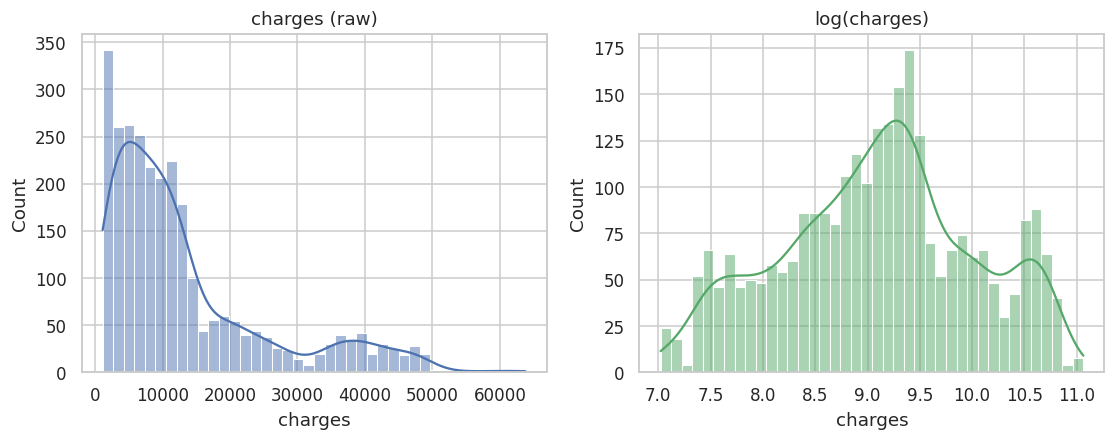

skew raw = 1.511 | skew log = -0.089


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["charges"], bins=40, kde=True, color="#4C72B0", ax=ax[0]); ax[0].set_title("charges (raw)")
sns.histplot(np.log(df["charges"]), bins=40, kde=True, color="#55A868", ax=ax[1]); ax[1].set_title("log(charges)")
plt.show()
print("skew raw =", round(df['charges'].skew(),3), "| skew log =", round(np.log(df['charges']).skew(),3))

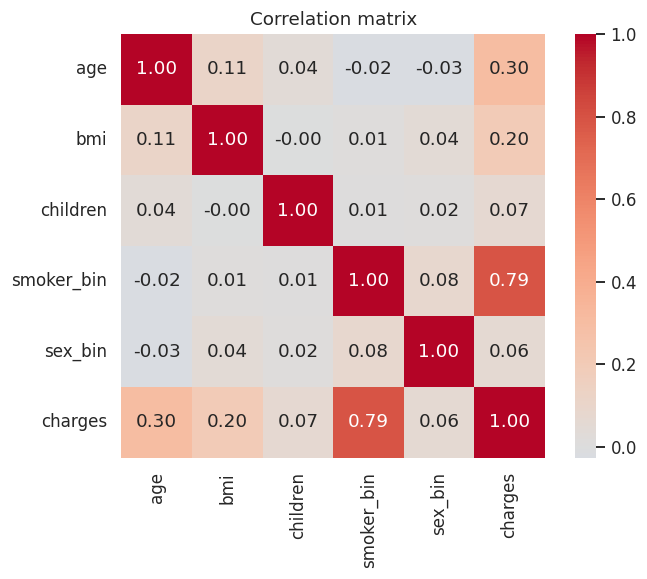

smoker_bin    0.789
age           0.299
bmi           0.200
children      0.066
sex_bin       0.063
Name: charges, dtype: float64


In [4]:
enc = df.copy()
enc["smoker_bin"] = (enc["smoker"]=="yes").astype(int)
enc["sex_bin"] = (enc["sex"]=="male").astype(int)
corr = enc[["age","bmi","children","smoker_bin","sex_bin","charges"]].corr()
plt.figure(figsize=(7,5)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix"); plt.show()
print(corr["charges"].drop("charges").sort_values(ascending=False).round(3))

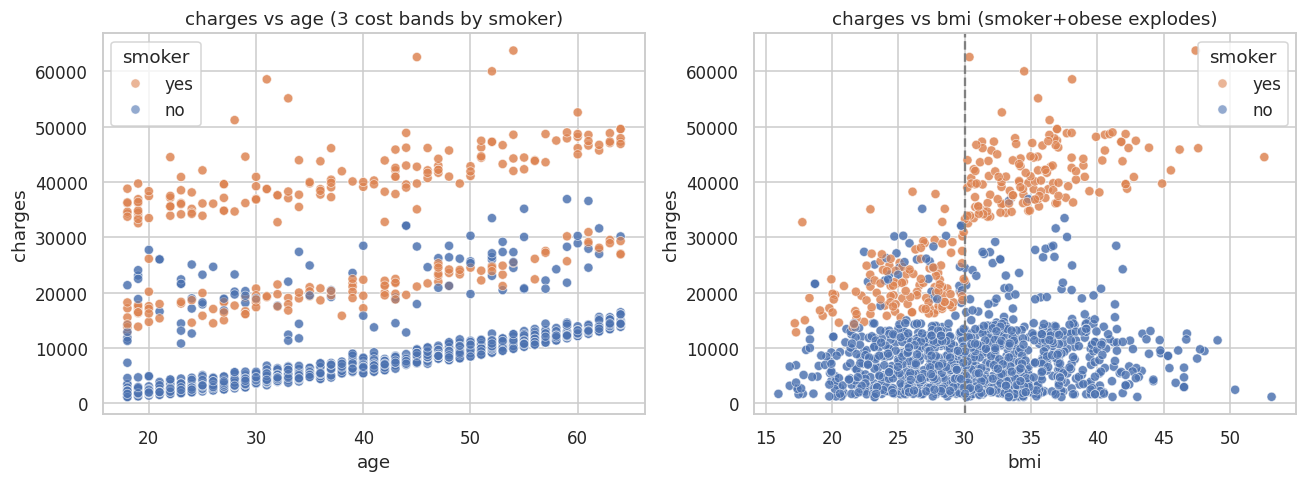

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", palette=PALETTE, alpha=.6, ax=ax[0])
ax[0].set_title("charges vs age (3 cost bands by smoker)")
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", palette=PALETTE, alpha=.6, ax=ax[1])
ax[1].axvline(30, ls="--", c="grey"); ax[1].set_title("charges vs bmi (smoker+obese explodes)")
plt.show()

**Key relationships.** `smoker` is by far the dominant driver (corr ≈ 0.79). Smokers split into
two bands by BMI: smokers with **BMI ≥ 30** incur dramatically higher charges. Age adds a steady,
slightly accelerating cost gradient. These interactions motivate the engineered features below.


## Stage 2 — Data Preprocessing & Feature Engineering

**Decisions**
- **Missing values:** none → no imputation.
- **De-duplication (leakage prevention):** drop exact duplicates **before** splitting so identical
  records cannot appear in both train and test (which would inflate scores). 2,772 → 1,337 rows.
- **Encoding:** one-hot (`drop="first"`) for low-cardinality nominal `sex, smoker, region`.
- **Scaling:** `StandardScaler` on numerics — required for the linear baseline's coefficient
  comparability; harmless for trees.
- **Feature engineering (≥1 non-trivial):**
  - `smoker_obese` = smoker × (BMI≥30) **interaction** — isolates the highest-cost segment.
  - `age2` = age² — captures the accelerating, non-linear age effect.
  - `obese` = BMI≥30 clinical flag.
- **Split:** 80/20 random (no time ordering; continuous target → no stratification needed).


In [6]:
df = df.drop_duplicates().reset_index(drop=True)
print("After de-dup:", df.shape)

df["obese"] = (df["bmi"] >= 30).astype(int)
df["smoker_bin"] = (df["smoker"] == "yes").astype(int)
df["smoker_obese"] = df["smoker_bin"] * df["obese"]
df["age2"] = df["age"] ** 2
print("Mean charges by smoker_obese:\n", df.groupby("smoker_obese")["charges"].mean().round(0))

numeric = ["age","bmi","children","age2","smoker_obese","obese"]
categorical = ["sex","smoker","region"]
X = df[numeric + categorical]; y = df["charges"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
print("train:", X_train.shape, "test:", X_test.shape)

pre = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
])

After de-dup: (1337, 7)
Mean charges by smoker_obese:
 smoker_obese
0     9839.0
1    41558.0
Name: charges, dtype: float64
train: (1069, 9) test: (268, 9)


## Stage 3 — Model Selection & Justification

**Baseline — Linear Regression.** Charges rise roughly linearly with age and shift sharply by
smoker status. With the engineered interaction/`age²` terms, a linear model captures most of the
structure while remaining fully interpretable — the right transparent benchmark for a regulated
pricing context.

**Advanced — Gradient Boosting.** The data has **heavy tails, a threshold effect (BMI≥30) and a
strong smoker×BMI interaction**. Boosted trees model non-linear interactions automatically, are
robust to outliers and need no scaling — a natural fit. We also fit a tuned **Random Forest** as a
second non-linear reference. All hyper-parameters are tuned by **5-fold CV grid search** (not by eye).


## Stage 4 — Training, Tuning & Evaluation

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

def evaluate(name, model):
    model.fit(X_train, y_train)
    ptr, pte = model.predict(X_train), model.predict(X_test)
    row = {"model": name, "train_R2": r2_score(y_train, ptr), "test_R2": r2_score(y_test, pte),
           "test_MAE": mean_absolute_error(y_test, pte),
           "test_RMSE": np.sqrt(mean_squared_error(y_test, pte))}
    results.append(row); print(name, {k: round(v,3) if isinstance(v,float) else v for k,v in row.items()})
    return model, pte

lin = Pipeline([("pre", pre), ("model", LinearRegression())])
print("CV R2 (linear):", round(cross_val_score(lin, X_train, y_train, cv=cv, scoring="r2").mean(),4))
lin, pred_lin = evaluate("Linear Regression", lin)

CV R2 (linear): 0.8471
Linear Regression {'model': 'Linear Regression', 'train_R2': 0.852, 'test_R2': 0.906, 'test_MAE': 2393.891, 'test_RMSE': np.float64(4158.299)}


In [8]:
gbr = Pipeline([("pre", pre), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))])
grid = {"model__n_estimators":[200,400], "model__max_depth":[2,3],
        "model__learning_rate":[0.05,0.1], "model__subsample":[0.8,1.0]}
gs = GridSearchCV(gbr, grid, cv=cv, scoring="r2", n_jobs=-1).fit(X_train, y_train)
print("Best GBR params:", gs.best_params_, "| CV R2:", round(gs.best_score_,4))
best_gbr = gs.best_estimator_
_, pred_gbr = evaluate("Gradient Boosting", best_gbr)

rf = Pipeline([("pre", pre), ("model", RandomForestRegressor(random_state=RANDOM_STATE))])
grid_rf = {"model__n_estimators":[300,500], "model__max_depth":[None,6,10], "model__min_samples_leaf":[1,3]}
gs_rf = GridSearchCV(rf, grid_rf, cv=cv, scoring="r2", n_jobs=-1).fit(X_train, y_train)
print("Best RF params:", gs_rf.best_params_)
_, pred_rf = evaluate("Random Forest", gs_rf.best_estimator_)

Best GBR params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200, 'model__subsample': 1.0} | CV R2: 0.845
Gradient Boosting {'model': 'Gradient Boosting', 'train_R2': 0.869, 'test_R2': 0.902, 'test_MAE': 2450.922, 'test_RMSE': np.float64(4237.332)}


Best RF params: {'model__max_depth': 6, 'model__min_samples_leaf': 3, 'model__n_estimators': 300}


Random Forest {'model': 'Random Forest', 'train_R2': 0.877, 'test_R2': 0.902, 'test_MAE': 2370.274, 'test_RMSE': np.float64(4234.543)}


,model,train_R2,test_R2,test_MAE,test_RMSE,lift_R2_vs_baseline,MAE_reduction
0,Linear Regression,0.852,0.906,2393.891,4158.299,0.000,0.000
1,Gradient Boosting,0.869,0.902,2450.922,4237.332,-0.004,-57.032
2,Random Forest,0.877,0.902,2370.274,4234.543,-0.003,23.616


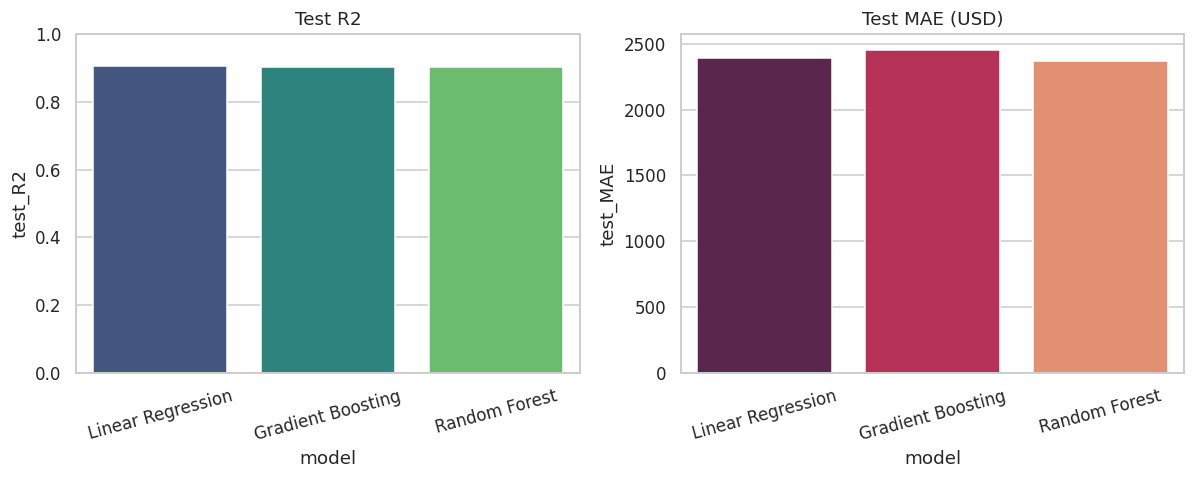

In [9]:
res = pd.DataFrame(results)
res["lift_R2_vs_baseline"] = res["test_R2"] - res.loc[0,"test_R2"]
res["MAE_reduction"] = res.loc[0,"test_MAE"] - res["test_MAE"]
display(res.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13,4))
sns.barplot(data=res, x="model", y="test_R2", palette="viridis", ax=ax[0]); ax[0].set_ylim(0,1); ax[0].set_title("Test R2")
sns.barplot(data=res, x="model", y="test_MAE", palette="rocket", ax=ax[1]); ax[1].set_title("Test MAE (USD)")
for a in ax: a.tick_params(axis="x", rotation=15)
plt.show()

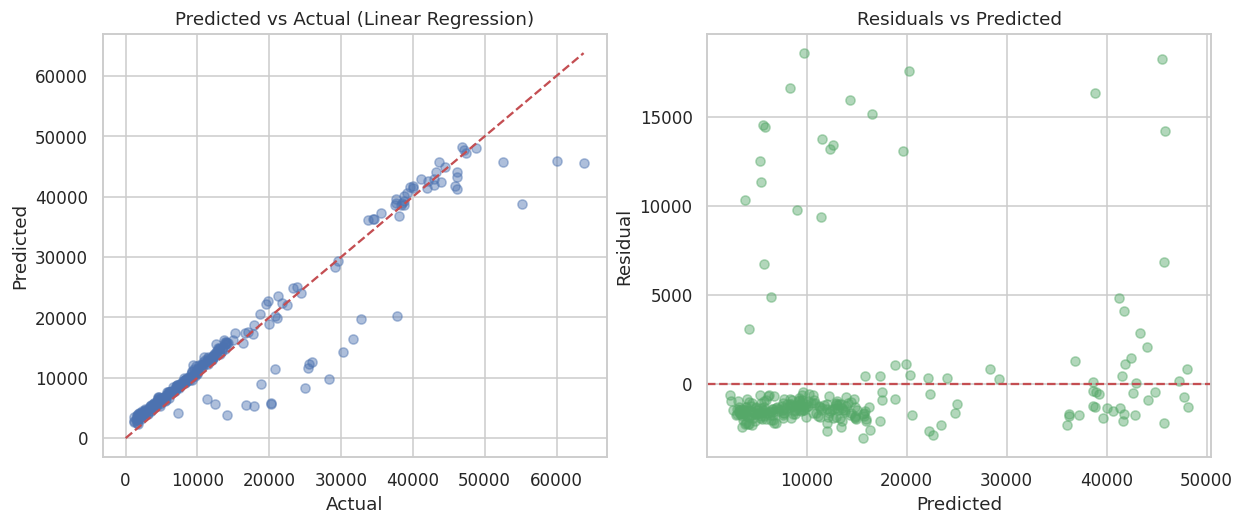

In [10]:
best_name = res.loc[res['test_R2'].idxmax(),'model']
best_pred = {"Linear Regression":pred_lin,"Gradient Boosting":pred_gbr,"Random Forest":pred_rf}[best_name]
fig, ax = plt.subplots(1,2, figsize=(13,5))
ax[0].scatter(y_test, best_pred, alpha=.45); lims=[0,max(y_test.max(),best_pred.max())]
ax[0].plot(lims, lims, "r--"); ax[0].set_title(f"Predicted vs Actual ({best_name})")
ax[0].set_xlabel("Actual"); ax[0].set_ylabel("Predicted")
resid = y_test.values - best_pred
ax[1].scatter(best_pred, resid, alpha=.45, color="#55A868"); ax[1].axhline(0, ls="--", c="r")
ax[1].set_title("Residuals vs Predicted"); ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Residual")
plt.show()

## Stage 5 — Result Interpretation & Business Conclusion

,feature,importance
0,smoker_obese,0.4094
1,smoker_yes,0.3878
2,age2,0.0707
3,bmi,0.0691
4,age,0.0513
5,children,0.0106
6,region_southwest,0.0007
7,sex_male,0.0003
8,region_southeast,0.0001
9,region_northwest,0.0000


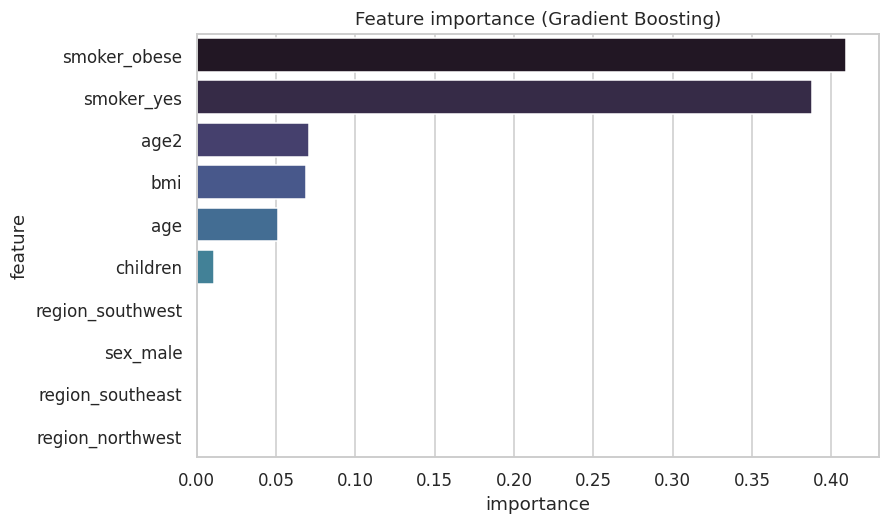

In [11]:
model = best_gbr.named_steps["model"]
cat_names = list(best_gbr.named_steps["pre"].named_transformers_["cat"].get_feature_names_out(categorical))
imp = (pd.DataFrame({"feature": numeric+cat_names, "importance": model.feature_importances_})
       .sort_values("importance", ascending=False).reset_index(drop=True))
display(imp.round(4))
plt.figure(figsize=(8,5)); sns.barplot(data=imp.head(10), x="importance", y="feature", palette="mako")
plt.title("Feature importance (Gradient Boosting)"); plt.show()

### Business conclusion

- **Performance.** All three models explain ≈ **90% of the variance** in charges (test R² ≈ 0.90),
  with an average error (MAE) of roughly **$2,400** per member. Crucially, the **interpretable Linear
  Regression baseline matches the tuned trees** once the smoker×obesity interaction and age² terms
  are added — a case where a well-justified simple model wins (and is preferable in a regulated
  pricing setting).
- **Top drivers & economic intuition.** `smoker`, the `smoker_obese` interaction, `age`/`age²` and
  `bmi` dominate; `region` and `sex` are negligible. Smoking and obesity-driven chronic risk are the
  economic engines of medical cost; age proxies accumulated health risk.
- **Limitations (honest).** (1) Only 1,337 unique records → modest sample; (2) original file's
  duplication is a real leakage trap — addressed by de-dup; (3) features are coarse (no diagnosis/claims
  history); (4) `sex`/`region` near-zero importance means the model is fair on those axes but also blind
  to genuine regional cost variation; (5) charges are right-skewed — large claims have wider error.
- **Recommendations.**
  1. **Risk-based pricing surcharge** for smokers, escalating with BMI — the single largest, most
     defensible lever.
  2. **Targeted wellness / smoking-cessation & weight-management programmes** for the smoker-obese
     segment, where expected savings per member are largest.
  3. **Deploy the interpretable linear model** for premium quoting (auditable, regulator-friendly),
     keeping gradient boosting as a challenger/monitoring model.
